In [2]:
import pandas as pd
import numpy as np
import arff
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

In [3]:
pip install liac-arff

Looking in indexes: http://pypi.k.avito.ru/pypi/
  Preparing metadata (setup.py) ... - done
  DEPRECATION: Building 'liac-arff' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'liac-arff'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11770 sha256=a66cf0a9a0714b3549f56cc2ad7f6d53121226de051930f625f848e2adb6a624
  Stored in directory: /home/jovyan/.cache/pip/wheels/19/fc/2f/b22f8a74628cfe03f6aa02d4ef81c89e8ad897f2d81277198d
Successfully built liac-arff
Note: you may need to restart the kernel to use updated packages.


In [3]:
with open('dataset.-2', 'r', encoding='utf-8') as f:
    datafile = arff.load(f)

df_unitial = pd.DataFrame(datafile['data'], columns=[attr[0] for attr in datafile['attributes']])

df_unitial.head()

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [6]:
df_unitial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  object 
 1   Age                                    27901 non-null  float64
 2   City                                   27901 non-null  object 
 3   Profession                             27901 non-null  object 
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA                                   27901 non-null  float64
 7   Study Satisfaction                     27901 non-null  float64
 8   Job Satisfaction                       27901 non-null  float64
 9   Sleep Duration                         27901 non-null  object 
 10  Dietary Habits                         27901 non-null  object 
 11  De

In [4]:
df = df_unitial.copy()

In [5]:
df.rename(columns={
    'Gender': 'gender',
    'Age': 'age',
    'Profession': 'profession',
    'City': 'city',
    'Academic Pressure': 'academic_pressure',
    'Work Pressure': 'work_pressure',
    'CGPA': 'cgpa',
    'Study Satisfaction': 'study_satisfaction',
    'Job Satisfaction': 'job_satisfaction',
    'Sleep Duration': 'sleep_duration',
    'Dietary Habits': 'dietary_habits',
    'Degree': 'degree',
    'Have you ever had suicidal thoughts ?': 'suicidal_thoughts',
    'Work/Study Hours': 'study_hours',
    'Financial Stress': 'financial_stress',
    'Family History of Mental Illness': 'family_mental_ilness',
    'Depression': 'depression'
    }, inplace=True)

<Figure size 1200x600 with 0 Axes>

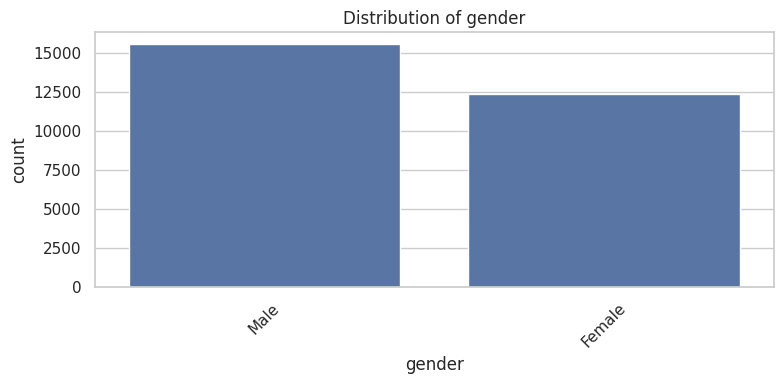

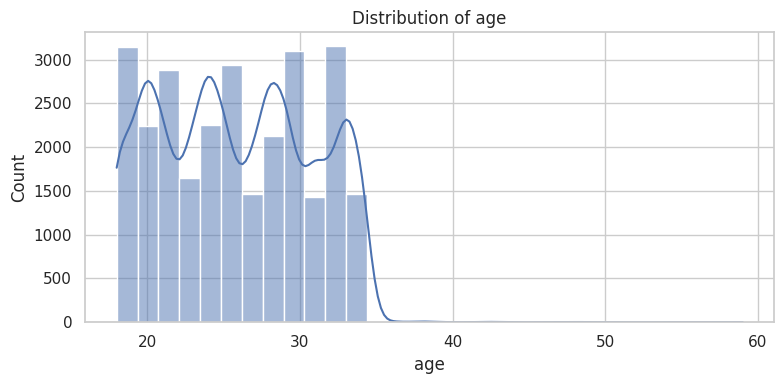

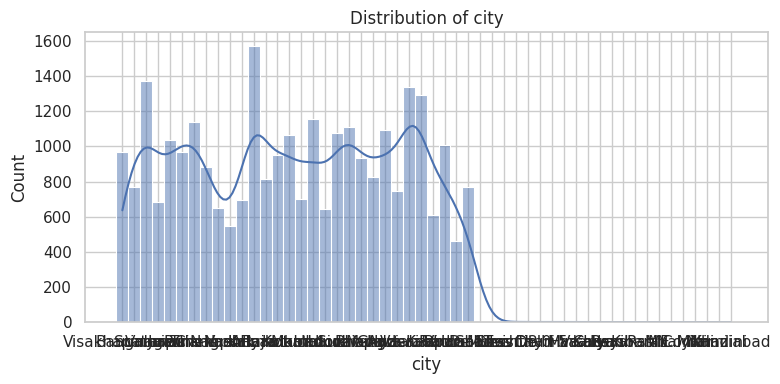

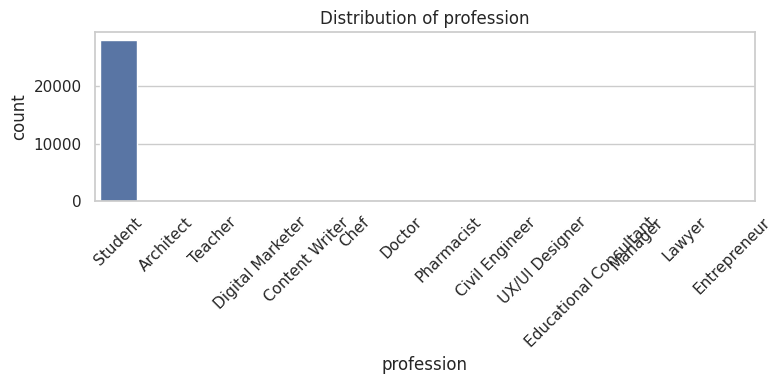

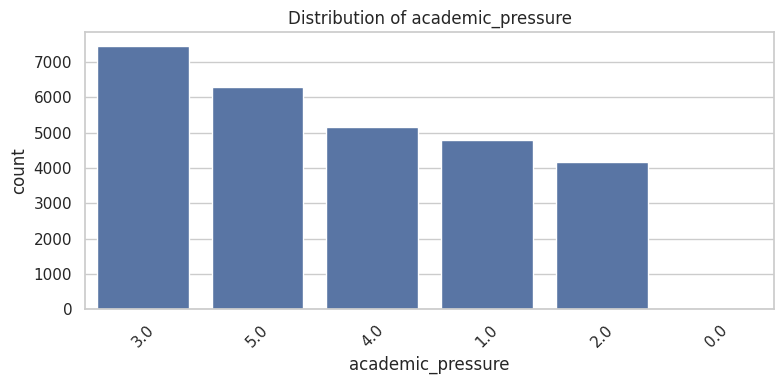

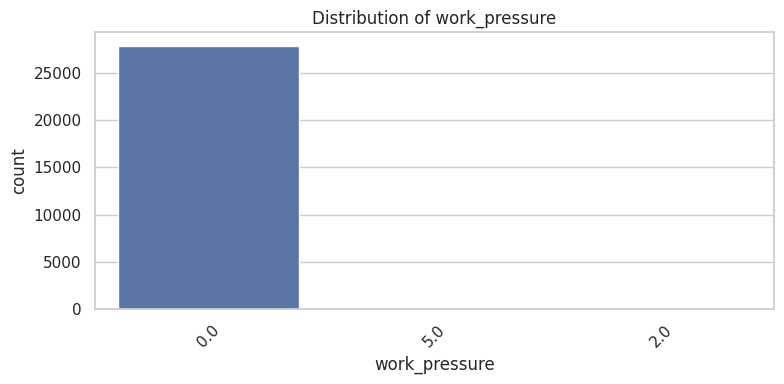

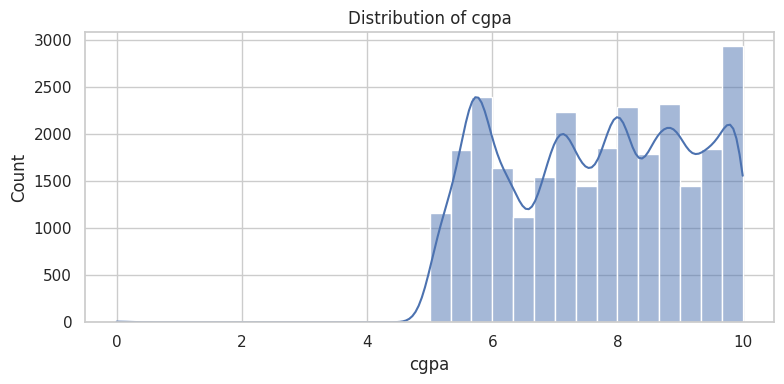

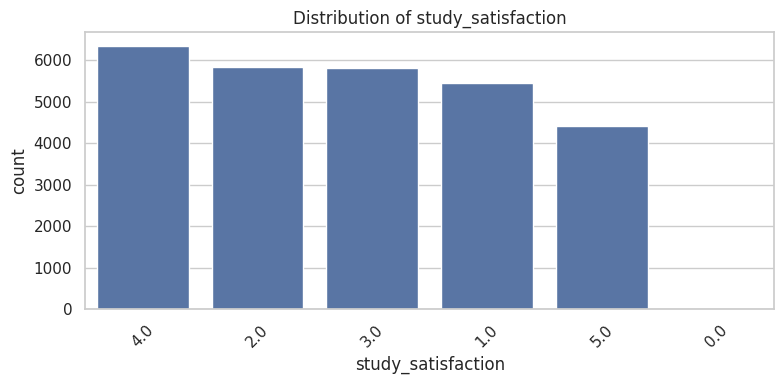

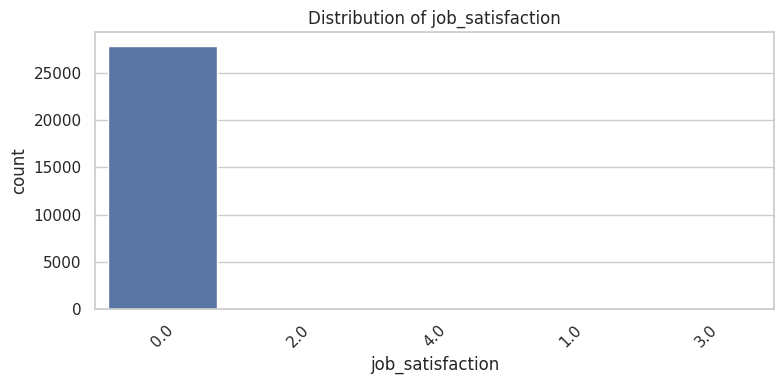

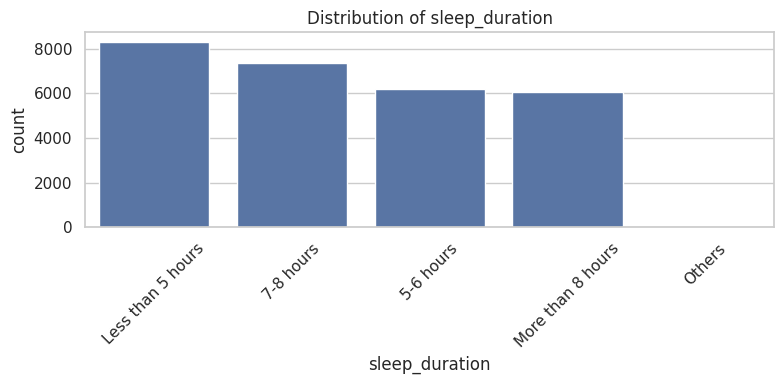

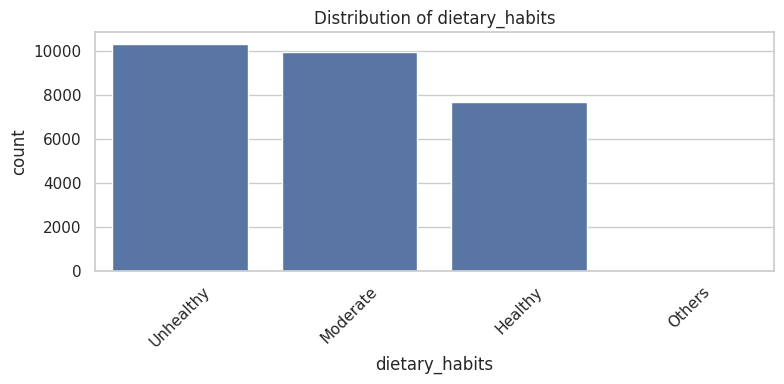

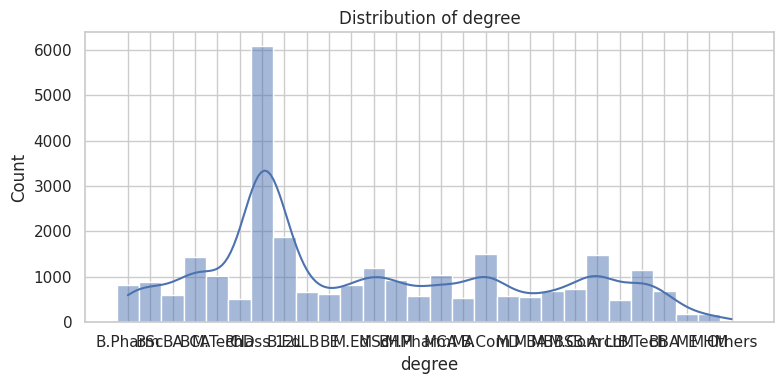

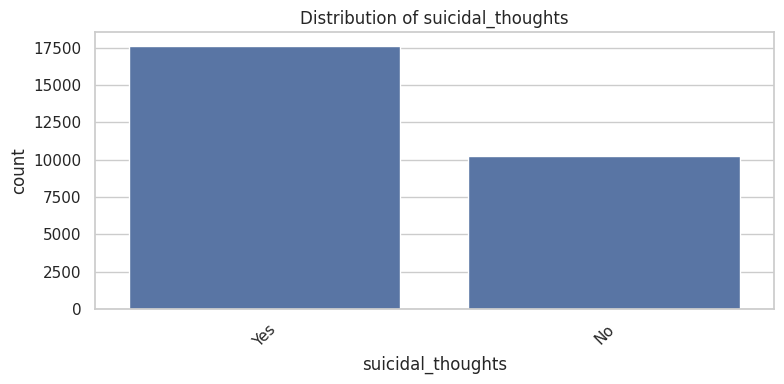

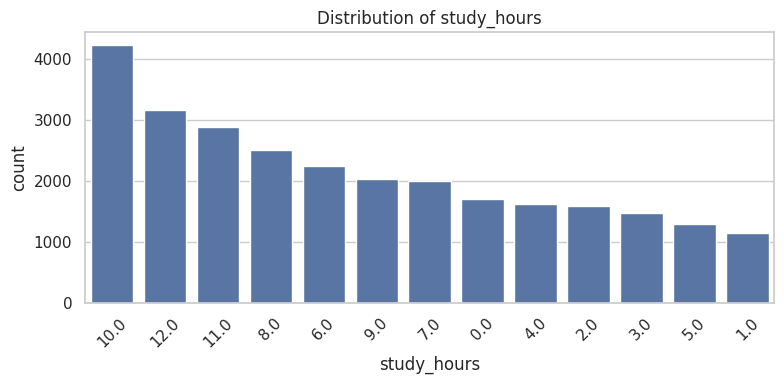

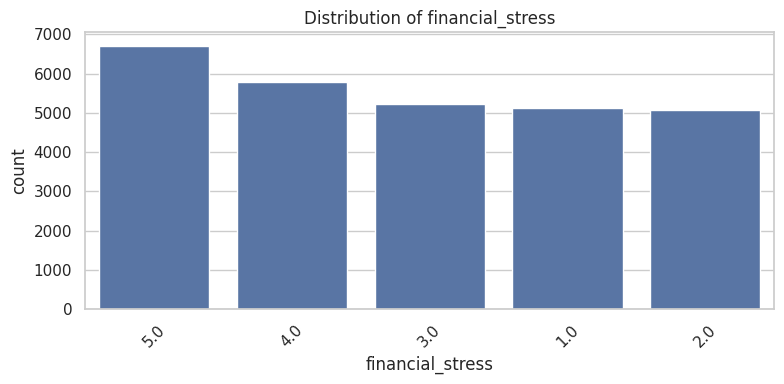

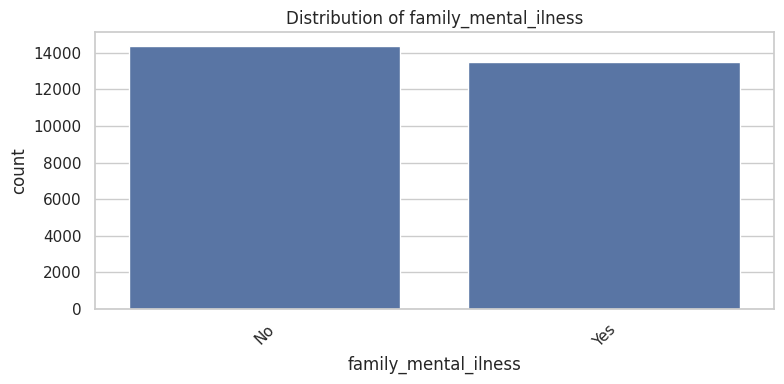

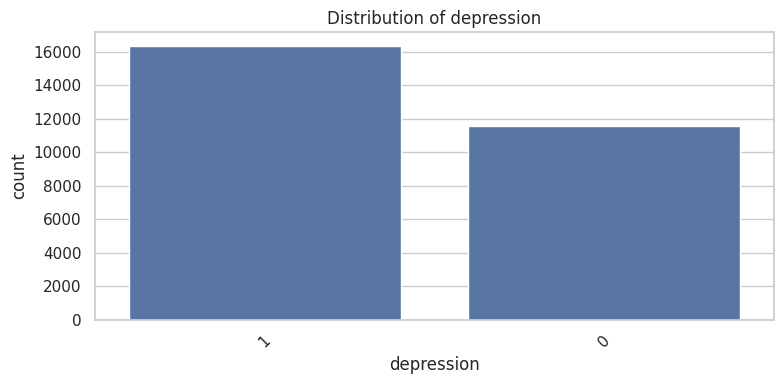

In [95]:
# features and target distribution
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

for col in df.columns:
    plt.figure(figsize=(8, 4))

    if df[col].dtype == 'category' or df[col].nunique() < 15:
        if col == "city" or col == "degree":
          sns.countplot(x=col, data=df, order=df[col].value_counts().iloc[:10].index)
          plt.title(f'Top 10 values {col}')
          plt.xticks(rotation=45)
        else:
          sns.countplot(x=col, data=df, order=df[col].value_counts().index)
          plt.title(f'Distribution of {col}')
          plt.xticks(rotation=45)
    else:
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')

    plt.tight_layout()
    plt.show()


In [6]:
# deleting columns job_satisfaction, work_pressure, profession (almost all rows have only one meaning in these columns)
df.drop(columns=["job_satisfaction", "work_pressure", "profession"], inplace=True)

In [7]:
# Columns sleep_duration and dietary_habits are by design - ordinal but since there are values 'Others' we cannot preprocess them as ordinal
# Possible solution - get rid of rows with 'Others' if they are not numerous

sleep_duration_counts = df['sleep_duration'].value_counts()
dietary_habits_counts = df['dietary_habits'].value_counts()
print(sleep_duration_counts)
print()
print(dietary_habits_counts)

sleep_duration
Less than 5 hours    8310
7-8 hours            7346
5-6 hours            6183
More than 8 hours    6044
Others                 18
Name: count, dtype: int64

dietary_habits
Unhealthy    10317
Moderate      9921
Healthy       7651
Others          12
Name: count, dtype: int64


In [8]:
# deleting rows from df where value in columns 'sleep_duration', 'dietary_habits' is 'Others'

df = df[~df[['sleep_duration', 'dietary_habits']].isin(['Others']).any(axis=1)]

Ordinal features:

- academic_pressure (already in numeric form, needs Z-score standardisation / Min-Max scaling)
- study_satisfaction (already in numeric form, needs Z-score standardisation / Min-Max scaling)
- sleep_duration (needs numeric mapping, then needs Z-score standardisation / Min-Max scaling)
- financial_stress (already in numeric form, needs Z-score standardisation / Min-Max scaling)

Categorincal features:

- gender (needs OHE)
- city (needs OHE)
- dietary_habits (needs OHE)
- degree (needs OHE)
- suicidal_thoughts (needs label encoding)
- family_mental_ilness (needs label encoding)

Numerical (ratio) features:

- age (needs Z-score standardisation / Min-Max scaling)
- cgpa (needs Z-score standardisation / Min-Max scaling)
- study_hours (needs Z-score standardisation / Min-Max scaling)

In [9]:
# function for numerical mapping for 'sleep_duration':
# - 'Less than 5 hours' - 5
# - '5-6 hours' - 5.5
# - '7-8 hours' - 7.5
# - 'More than 8 hours' - 8
# name a new column as 'sleep_duration_final'


def map_sleep_duration(df):
    mapping = {
        'Less than 5 hours': 5,
        '5-6 hours': 5.5,
        '7-8 hours': 7.5,
        'More than 8 hours': 8
    }
    df['sleep_duration'] = df['sleep_duration'].map(mapping)
    return df

In [10]:
# function for label encoding for 'suicidal_thoughts' and 'family_mental_ilness': 1 if 'Yes', 0 if 'No'
def label_encoding(df):
    df['suicidal_thoughts'] = df['suicidal_thoughts'].map({'Yes': 1, 'No': 0})
    df['family_mental_ilness'] = df['family_mental_ilness'].map({'Yes': 1, 'No': 0})
    return df


In [12]:
# function for one hot encoding 
columns_for_ohe = ['gender', 'city', 'dietary_habits', 'degree']

def one_hot_encoding(df, columns_for_ohe):
    return pd.get_dummies(df, columns=columns_for_ohe, drop_first=True).replace({True: 1, False: 0})

# df_encoded = one_hot_encode(df, ['gender', 'city', 'dietary_habits', 'degree'])

In [13]:
# Apply preprocessing for categorical values

df_encoded_pre = map_sleep_duration(df)
df_encoded_pre = label_encoding(df_encoded_pre)
df_encoded_pre = one_hot_encoding(df_encoded_pre, columns_for_ohe)

#df_encoded_pre.head()

In [14]:
df_shuffled = df_encoded_pre.sample(frac=1, random_state=42).reset_index(drop=True)
df_shuffled.to_csv('depression_shuffled_notscaled.csv', index=False)